In [1]:
# cell 1 - imports and reproducibility
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import random, os, time
import ot
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"PyTorch {torch.__version__} | torchvision {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

2026-06-09 03:02:23.179357: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780974143.367048     146 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780974143.422800     146 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780974143.889111     146 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780974143.889153     146 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780974143.889156     146 computation_placer.cc:177] computation placer alr

PyTorch 2.3.1+cu121 | torchvision 0.18.1+cu121
CUDA available: True
Device: cuda


In [2]:
# cell 2 - load MNIST (grayscale, 28x28)
mnist_transform = transforms.Compose([transforms.ToTensor()])
mnist_train = torchvision.datasets.MNIST(root='/kaggle/working/data', train=True, download=True, transform=mnist_transform)
mnist_test = torchvision.datasets.MNIST(root='/kaggle/working/data', train=False, download=True, transform=mnist_transform)
print(f"MNIST train: {len(mnist_train)} | test: {len(mnist_test)}")
print(f"Image shape: {mnist_train[0][0].shape}") # (1, 28, 28)
print(f"Label range: {min(mnist_train.targets.numpy())} – {max(mnist_train.targets.numpy())}")

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:00<00:00, 16844608.56it/s]


Extracting /kaggle/working/data/MNIST/raw/train-images-idx3-ubyte.gz to /kaggle/working/data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 452969.02it/s]


Extracting /kaggle/working/data/MNIST/raw/train-labels-idx1-ubyte.gz to /kaggle/working/data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:00<00:00, 4194476.98it/s]


Extracting /kaggle/working/data/MNIST/raw/t10k-images-idx3-ubyte.gz to /kaggle/working/data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 6654044.28it/s]

Extracting /kaggle/working/data/MNIST/raw/t10k-labels-idx1-ubyte.gz to /kaggle/working/data/MNIST/raw

MNIST train: 60000 | test: 10000
Image shape: torch.Size([1, 28, 28])
Label range: 0 – 9


In [3]:
# cell 3 - load SVHN (rgb, 32x32)
svhn_transform = transforms.Compose([transforms.ToTensor()])
svhn_train = torchvision.datasets.SVHN(root='/kaggle/working/data', split='train', download=True, transform=svhn_transform)
svhn_test = torchvision.datasets.SVHN(root='/kaggle/working/data', split='test',  download=True, transform=svhn_transform)
print(f"SVHN  train: {len(svhn_train)} | test: {len(svhn_test)}")
print(f"Image shape: {svhn_train[0][0].shape}") # (3, 32, 32)
print(f"Label range: {min(svhn_train.labels)} – {max(svhn_train.labels)}")

100%|██████████| 182040794/182040794 [00:10<00:00, 17822680.44it/s]


100%|██████████| 64275384/64275384 [00:04<00:00, 13019672.77it/s]


SVHN  train: 73257 | test: 26032
Image shape: torch.Size([3, 32, 32])
Label range: 0 – 9


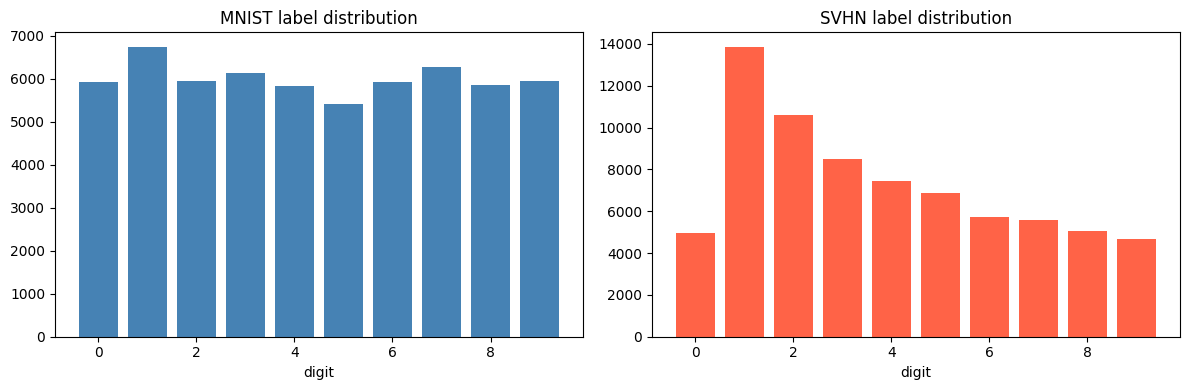

In [4]:
# cell 4 - label distributions side-by-side
mnist_labels = mnist_train.targets.numpy()
svhn_labels = svhn_train.labels # numpy array

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(*np.unique(mnist_labels, return_counts=True), color='steelblue')
axes[0].set_title("MNIST label distribution"); axes[0].set_xlabel("digit")
axes[1].bar(*np.unique(svhn_labels,  return_counts=True), color='tomato')
axes[1].set_title("SVHN label distribution");  axes[1].set_xlabel("digit")
plt.tight_layout(); plt.show()

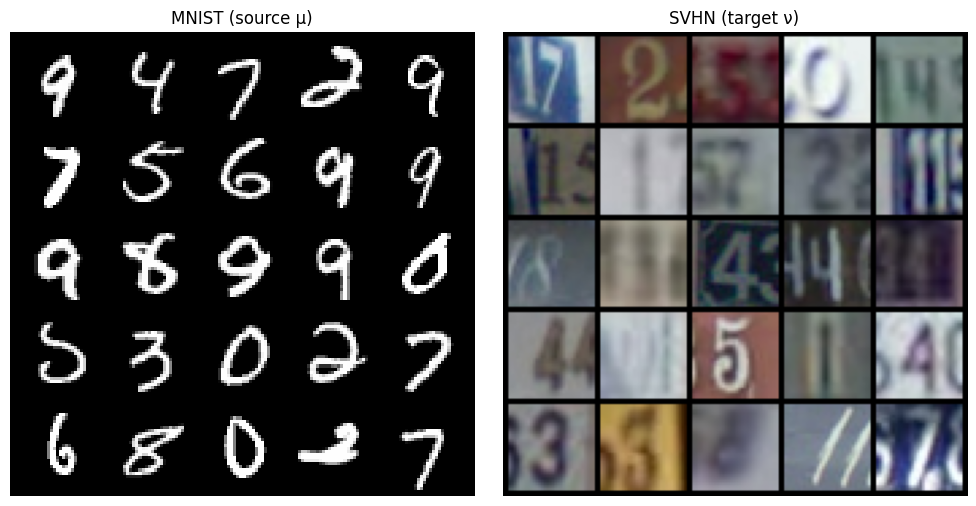

In [5]:
# cell 5 - 5×5 sample grid: MNIST (left) and SVHN (right)
def make_grid_figure(dataset, n=5, title="", gray=False):
    indices = random.sample(range(len(dataset)), n*n)
    imgs = [dataset[i][0] for i in indices]
    grid = torchvision.utils.make_grid(imgs, nrow=n, padding=2, normalize=True)
    return grid.permute(1,2,0).numpy() if not gray else grid[0].numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# MNIST: (1,28,28) → replicate to 3 channels for display
mnist_imgs = [mnist_train[i][0].repeat(3,1,1) for i in random.sample(range(len(mnist_train)), 25)]
svhn_imgs = [svhn_train[i][0] for i in random.sample(range(len(svhn_train)), 25)]
for ax, imgs, ttl in zip(axes, [mnist_imgs, svhn_imgs], ["MNIST (source μ)", "SVHN (target ν)"]):
    grid = torchvision.utils.make_grid(imgs, nrow=5, padding=2, normalize=True)
    ax.imshow(grid.permute(1,2,0).numpy()); ax.set_title(ttl); ax.axis('off')
plt.tight_layout(); plt.show()

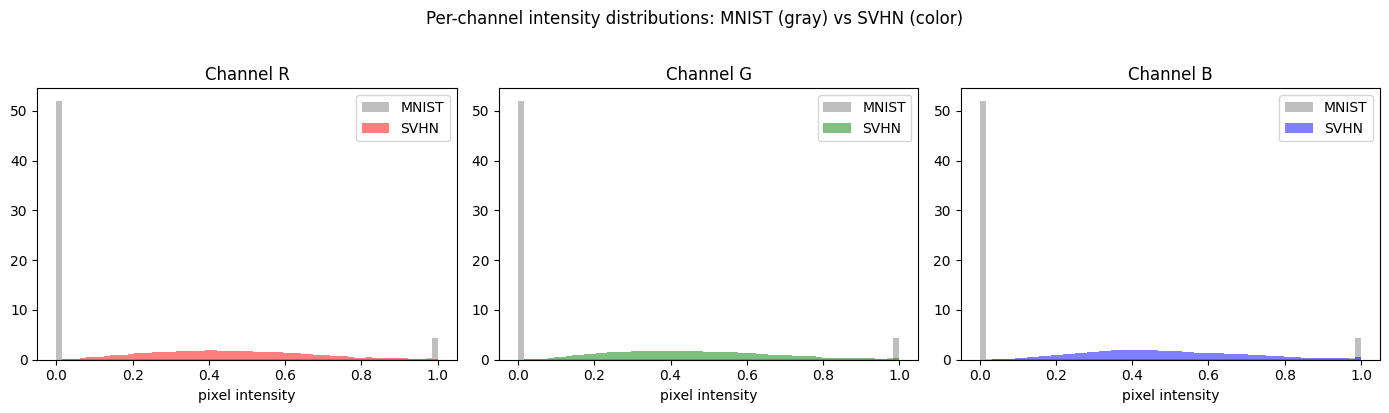

In [6]:
# cell 6 - per-channel intensity histograms overlaid
# MNIST is 1-channel; we replicate it to 3 channels to compare on the same axes.
# sample 2000 images from each domain for speed.
N = 2000
mnist_sample = torch.stack([mnist_train[i][0].repeat(3,1,1) for i in range(N)]) # (N,3,28,28)
svhn_sample = torch.stack([svhn_train[i][0] for i in range(N)]) # (N,3,32,32)

colors = ['red','green','blue']
ch_names = ['R','G','B']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for c, (ax, col, ch) in enumerate(zip(axes, colors, ch_names)):
    ax.hist(mnist_sample[:,c].flatten().numpy(), bins=64, alpha=0.5, color='gray', density=True, label='MNIST')
    ax.hist(svhn_sample[:,c].flatten().numpy(), bins=64, alpha=0.5, color=col, density=True, label='SVHN')
    ax.set_title(f"Channel {ch}"); ax.set_xlabel("pixel intensity"); ax.legend()
plt.suptitle("Per-channel intensity distributions: MNIST (gray) vs SVHN (color)", y=1.02)
plt.tight_layout(); plt.show()

In [7]:
# cell 7 - quantify domain gap: per-channel mean and std
for name, tensor in [("MNIST (replicated)", mnist_sample), ("SVHN", svhn_sample)]:
    means = tensor.mean(dim=(0,2,3))
    stds = tensor.std(dim=(0,2,3))
    print(f"{name}")
    for c, ch in enumerate(['R','G','B']):
        print(f" {ch}: mean={means[c]:.4f} std={stds[c]:.4f}")
    print()

MNIST (replicated)
 R: mean=0.1302 std=0.3077
 G: mean=0.1302 std=0.3077
 B: mean=0.1302 std=0.3077

SVHN
 R: mean=0.4507 std=0.2028
 G: mean=0.4566 std=0.2072
 B: mean=0.4845 std=0.2038



In [8]:
# cell 8 - exact 1D W1 via sorted quantile formula
def w1_sorted(x: torch.Tensor, y: torch.Tensor) -> float:
    """
    Computes W1(mu, nu) for two equal-sized 1D empirical distributions.
    Complexity: O(n log n) due to sort. Formula: (1/n) * sum |x_(i) - y_(i)|.
    """
    assert x.shape == y.shape and x.ndim == 1
    return (x.sort().values - y.sort().values).abs().mean().item()

# sanity check: identical distributions -> distance = 0
x = torch.linspace(0, 1, 1000)
assert w1_sorted(x, x) == 0.0
print("Identical distributions: W1 =", w1_sorted(x, x))

# well-separated distributions -> nonzero
y = torch.linspace(2, 3, 1000)
print("Separated by 2 units:   W1 =", w1_sorted(x, y)) # expect ~2.0

Identical distributions: W1 = 0.0
Separated by 2 units:   W1 = 2.0


In [9]:
# cell 9 - verify against POT
def w1_pot(x: torch.Tensor, y: torch.Tensor) -> float:
    """POT reference: exact W1 via linear program."""
    xn, yn = x.numpy(), y.numpy()
    n = len(xn)
    a, b = np.ones(n)/n, np.ones(n)/n
    M = ot.dist(xn.reshape(-1,1), yn.reshape(-1,1), metric='euclidean')
    return ot.emd2(a, b, M)

# compare on random samples from two Gaussians
p = torch.randn(500) * 0.5 + 0.0 # N(0, 0.5)
q = torch.randn(500) * 0.5 + 1.5 # N(1.5, 0.5)

ours = w1_sorted(p, q)
ref  = w1_pot(p, q)
print(f"Our W1: {ours:.6f}")
print(f"POT W1: {ref:.6f}")
print(f"Abs err: {abs(ours - ref):.2e}")
assert abs(ours - ref) < 1e-4, "mismatch — check implementation"
print("PASSED")

Our W1: 1.469894
POT W1: 1.469893
Abs err: 1.23e-06
PASSED


In [10]:
# cell 10 - complexity benchmark: O(n log n) empirically
sizes = [100, 500, 1000, 5000, 10000, 50000]
times = []
for n in sizes:
    a = torch.randn(n); b = torch.randn(n)
    t0 = time.perf_counter()
    for _ in range(20): w1_sorted(a, b)
    times.append((time.perf_counter() - t0) / 20)

for n, t in zip(sizes, times):
    print(f"n={n:>6} | time={t*1000:.3f} ms")

n=   100 | time=0.096 ms
n=   500 | time=0.083 ms
n=  1000 | time=0.191 ms
n=  5000 | time=0.886 ms
n= 10000 | time=1.792 ms
n= 50000 | time=10.108 ms


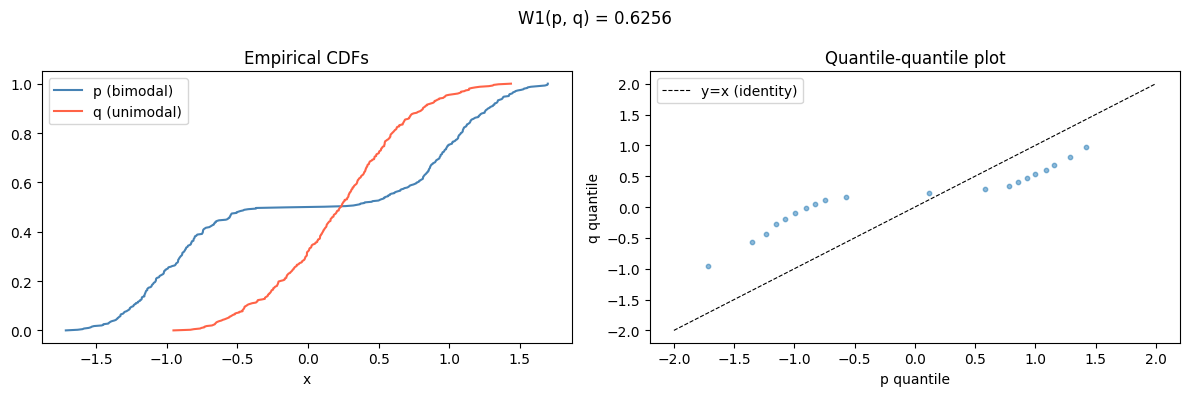

In [11]:
# cell 11 - visual: quantile matching on two toy distributions
p = torch.cat([torch.randn(200)*0.3 - 1.0, torch.randn(200)*0.3 + 1.0]) # bimodal (like MNIST)
q = torch.randn(400) * 0.5 + 0.2 # unimodal (like SVHN)

ps, qs = p.sort().values, q.sort().values
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: CDFs
axes[0].plot(ps.numpy(), torch.linspace(0,1,400).numpy(), label='p (bimodal)', color='steelblue')
axes[0].plot(qs.numpy(), torch.linspace(0,1,400).numpy(), label='q (unimodal)', color='tomato')
axes[0].set_title("Empirical CDFs"); axes[0].set_xlabel("x"); axes[0].legend()

# right: quantile-to-quantile matching (sample every 20th pair)
axes[1].scatter(ps[::20].numpy(), qs[::20].numpy(), alpha=0.5, s=10)
axes[1].plot([-2,2],[-2,2], 'k--', lw=0.8, label='y=x (identity)')
axes[1].set_title("Quantile-quantile plot"); axes[1].set_xlabel("p quantile"); axes[1].set_ylabel("q quantile")
axes[1].legend()

plt.suptitle(f"W1(p, q) = {w1_sorted(p, q):.4f}")
plt.tight_layout(); plt.show()

In [12]:
# cell 12 - W2 squared in 1D via sorted quantile
def w2_sq_sorted(x: torch.Tensor, y: torch.Tensor) -> float:
    """
    Computes W2^2(mu, nu) for equal-sized 1D empirical distributions.
    Formula: (1/n) * sum (x_(i) - y_(i))^2
    """
    assert x.shape == y.shape and x.ndim == 1
    return ((x.sort().values - y.sort().values) ** 2).mean().item()

# sanity checks
x = torch.linspace(0, 1, 1000)
assert w2_sq_sorted(x, x) == 0.0
y = torch.linspace(1, 2, 1000) # shifted by 1 -> W2^2 should be 1.0
print(f"Shifted by 1: W2^2 = {w2_sq_sorted(x, y):.6f}") # expect 1.0

Shifted by 1: W2^2 = 1.000000


In [13]:
# cell 13 - SWD from scratch
def sliced_wasserstein(X: torch.Tensor, Y: torch.Tensor, n_proj: int=100, seed: int=0) -> float:
    """
    SWD(mu, nu) = E_{theta ~ U(S^{d-1})} [W2^2(theta#mu, theta#nu)]
    X, Y: (n, d) sample matrices
    Projects both onto n_proj random directions, averages 1D W2^2.
    """
    assert X.shape[1] == Y.shape[1], "dimension mismatch"
    d = X.shape[1]
    rng = torch.Generator(); rng.manual_seed(seed)

    # sample unit vectors uniformly on S^{d-1}: normalize Gaussian draws
    thetas = torch.randn(n_proj, d, generator=rng) # (L, d)
    thetas = thetas / thetas.norm(dim=1, keepdim=True) # unit vectors

    # project: (n, d) @ (d, L) → (n, L), then transpose to (L, n)
    Xp = (X @ thetas.T).T # (L, n)
    Yp = (Y @ thetas.T).T # (L, n)

    # sort each projection independently
    Xps = Xp.sort(dim=1).values
    Yps = Yp.sort(dim=1).values

    # W2^2 per projection direction (mean over n samples), then average over L
    w2_per_proj = ((Xps - Yps) ** 2).mean(dim=1) # (L,)
    return w2_per_proj.mean().item() # scalar

In [14]:
# cell 14 - verify SWD against POT on 2D Gaussians
d = 2
X = torch.randn(500, d) * 0.5 # N(0, 0.5I)
Y = torch.randn(500, d) * 0.5 + torch.tensor([2., 2.]) # N((2,2), 0.5I)

swd_ours = sliced_wasserstein(X, Y, n_proj=2000, seed=0)

# POT reference: exact W2^2 in 2D
a = np.ones(500) / 500; b = np.ones(500) / 500
M = ot.dist(X.numpy(), Y.numpy(), metric='sqeuclidean')
swd_pot = ot.emd2(a, b, M)

print(f"SWD (ours, L=2000): {swd_ours:.4f}")
print(f"Full OT W2^2 (POT): {swd_pot:.4f}")
print(f"Note: SWD ≤ W2^2 in general — slicing is a lower bound, not exact")

SWD (ours, L=2000): 3.9901
Full OT W2^2 (POT): 7.9945
Note: SWD ≤ W2^2 in general — slicing is a lower bound, not exact


In [15]:
# cell 15 - convergence as L increases
Ls = [10, 50, 100, 500, 1000, 2000, 5000]
n_trials = 10

results = {}
for L in Ls:
    estimates = [sliced_wasserstein(X, Y, n_proj=L, seed=s) for s in range(n_trials)]
    results[L] = (np.mean(estimates), np.std(estimates))
    print(f"L={L:>5} | mean={results[L][0]:.4f} | std={results[L][1]:.4f}")

L=   10 | mean=4.1430 | std=0.8020
L=   50 | mean=4.0717 | std=0.2914
L=  100 | mean=4.0738 | std=0.3370
L=  500 | mean=3.9688 | std=0.1250
L= 1000 | mean=4.0097 | std=0.0738
L= 2000 | mean=3.9938 | std=0.0454
L= 5000 | mean=3.9827 | std=0.0215


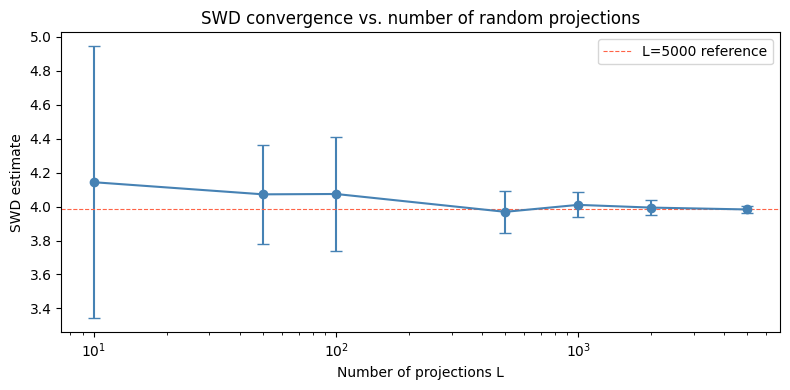

In [16]:
# cell 16 - plot convergence
means = [results[L][0] for L in Ls]
stds = [results[L][1] for L in Ls]

plt.figure(figsize=(8, 4))
plt.errorbar(Ls, means, yerr=stds, fmt='o-', capsize=4, color='steelblue')
plt.axhline(means[-1], color='tomato', ls='--', lw=0.8, label='L=5000 reference')
plt.xscale('log')
plt.xlabel("Number of projections L"); plt.ylabel("SWD estimate")
plt.title("SWD convergence vs. number of random projections")
plt.legend(); plt.tight_layout(); plt.show()

In [17]:
# cell 17 - triangle inequality verification setup
def swd_from_samples(X, Y, n_proj=500, seed=0):
    """wrapper returning scalar SWD (not squared) for metric verification."""
    return sliced_wasserstein(X, Y, n_proj=n_proj, seed=seed) ** 0.5

In [18]:
# cell 18 - generate 1000 random distribution triplets and test triangle inequality
n_triplets = 1000
n_samples = 200
d = 8 # non-trivial dimension
n_proj = 500
violations = []
margins = [] # swd(mu,rho) - swd(mu,nu) - swd(nu,rho); negative = satisfied

for t in range(n_triplets):
    # three distributions in distinct regions of R^d
    center_mu = torch.randn(d) * 3
    center_nu = torch.randn(d) * 3
    center_rho = torch.randn(d) * 3

    mu = torch.randn(n_samples, d) * 0.5 + center_mu
    nu = torch.randn(n_samples, d) * 0.5 + center_nu
    rho = torch.randn(n_samples, d) * 0.5 + center_rho

    # independent seeds per pair — worst-case test
    d_mu_rho = swd_from_samples(mu, rho, n_proj, seed=t*3+0)
    d_mu_nu = swd_from_samples(mu, nu, n_proj, seed=t*3+1)
    d_nu_rho = swd_from_samples(nu, rho, n_proj, seed=t*3+2)

    margin = d_mu_rho - d_mu_nu - d_nu_rho
    margins.append(margin)
    if margin > 0:
        violations.append(margin)

margins = np.array(margins)
print(f"Triplets tested: {n_triplets}")
print(f"Violations (margin>0): {len(violations)}")
print(f"Pass rate: {(n_triplets - len(violations))/n_triplets*100:.2f}%")
print(f"Max violation: {max(violations) if violations else 0:.6f}")
print(f"Mean margin: {margins.mean():.6f} (negative = satisfied with slack)")
print(f"Std of margin: {margins.std():.6f}")

Triplets tested: 1000
Violations (margin>0): 0
Pass rate: 100.00%
Max violation: 0.000000
Mean margin: -4.131103 (negative = satisfied with slack)
Std of margin: 1.658141


In [19]:
# cell 19 - repeat with shared directions (violations should vanish)
violations_shared = []
for t in range(n_triplets):
    center_mu = torch.randn(d) * 3
    center_nu = torch.randn(d) * 3
    center_rho = torch.randn(d) * 3

    mu = torch.randn(n_samples, d) * 0.5 + center_mu
    nu = torch.randn(n_samples, d) * 0.5 + center_nu
    rho = torch.randn(n_samples, d) * 0.5 + center_rho

    # same seed for all three pairs — shared projection directions
    d_mu_rho = swd_from_samples(mu, rho, n_proj, seed=t)
    d_mu_nu = swd_from_samples(mu, nu, n_proj, seed=t)
    d_nu_rho = swd_from_samples(nu, rho, n_proj, seed=t)

    margin = d_mu_rho - d_mu_nu - d_nu_rho
    if margin > 0:
        violations_shared.append(margin)

print(f"Shared directions — violations: {len(violations_shared)}/{n_triplets}")
print(f"Max violation: {max(violations_shared) if violations_shared else 0:.2e}")

Shared directions — violations: 0/1000
Max violation: 0.00e+00


In [20]:
# cell 20 - violation rate vs L
Ls_test = [10, 50, 100, 500, 1000]
for L in Ls_test:
    viols = 0
    for t in range(500):
        mu = torch.randn(200, d) * 0.5 + torch.randn(d)*3
        nu = torch.randn(200, d) * 0.5 + torch.randn(d)*3
        rho = torch.randn(200, d) * 0.5 + torch.randn(d)*3
        d1 = swd_from_samples(mu, rho, L, seed=t*3+0)
        d2 = swd_from_samples(mu, nu, L, seed=t*3+1)
        d3 = swd_from_samples(nu, rho, L, seed=t*3+2)
        if d1 - d2 - d3 > 0: viols += 1
    print(f"L={L:>5} violation rate: {viols/500*100:.1f}%")

L=   10 violation rate: 2.0%
L=   50 violation rate: 0.2%
L=  100 violation rate: 0.0%
L=  500 violation rate: 0.0%
L= 1000 violation rate: 0.0%


In [21]:
# cell 21 - differentiable W2^2 in 1D (must support autograd)
def w2_sq_differentiable(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    W2^2 for 1D projections. x, y: (n,) tensors.
    Sort is differentiable w.r.t. values via straight-through in PyTorch.
    """
    return ((x.sort().values - y.sort().values) ** 2).mean()

In [22]:
# cell 22 - max-SWD via projected gradient ascent
def max_sliced_wasserstein(X: torch.Tensor, Y: torch.Tensor, n_steps: int=100, lr: float=0.01, seed: int=0) -> tuple[float, torch.Tensor]:
    """
    Max-SWD(mu, nu) = max_{theta in S^{d-1}} W2^2(theta#mu, theta#nu)
    Optimization via projected gradient ascent on the unit sphere.
    Returns (max_w2_sq, optimal_theta).
    """
    d = X.shape[1]
    torch.manual_seed(seed)

    # random init on sphere
    theta = torch.randn(d)
    theta = theta / theta.norm()
    theta = theta.detach().requires_grad_(True)

    for _ in range(n_steps):
        # project both distributions onto current theta
        xp = X @ theta # (n,)
        yp = Y @ theta # (n,)
        loss = -w2_sq_differentiable(xp, yp) # negate: ascent via descent

        loss.backward()
        with torch.no_grad():
            theta.data = theta.data - lr * theta.grad # gradient step
            theta.data = theta.data / theta.data.norm() # project onto sphere
        theta.grad.zero_()

    with torch.no_grad():
        xp = X @ theta
        yp = Y @ theta
        val = w2_sq_differentiable(xp, yp).item()

    return val, theta.detach()

In [23]:
# cell 23 - compare Max-SWD vs SWD on the same distributions
d = 8
X = torch.randn(500, d) * 0.5
Y = torch.randn(500, d) * 0.5 + torch.tensor([2.] + [0.]*(d-1)) # gap only in dim 0

swd_val = sliced_wasserstein(X, Y, n_proj=2000, seed=0)
mswd_val, theta_star = max_sliced_wasserstein(X, Y, n_steps=200, lr=0.01)

print(f"SWD (L=2000): {swd_val:.4f}")
print(f"Max-SWD: {mswd_val:.4f}")
print(f"Max-SWD > SWD: {mswd_val > swd_val}")
print(f"\nOptimal theta* (first 4 dims): {theta_star[:4].numpy()}")
print(f"Expected: dominant weight on dim 0, near-zero elsewhere")
print(f"||theta*|| = {theta_star.norm().item():.6f}") # must be 1.0

SWD (L=2000): 0.4805
Max-SWD: 4.0349
Max-SWD > SWD: True

Optimal theta* (first 4 dims): [ 0.9990281  -0.01838604  0.01578108  0.00838822]
Expected: dominant weight on dim 0, near-zero elsewhere
||theta*|| = 1.000000


|theta* · e_0| = 0.9990 | (1.0 = perfect alignment)


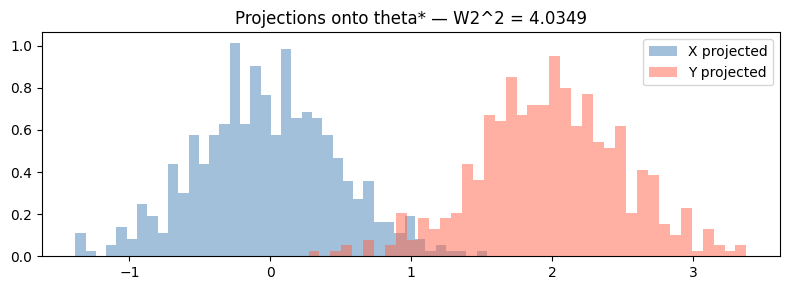

In [24]:
# cell 24 - verify theta* recovers the true direction of maximal separation
# since gap is along dim 0, theta* should align with e_0 = [1,0,0,...]
e0 = torch.zeros(d); e0[0] = 1.0
alignment = abs(theta_star @ e0).item()
print(f"|theta* · e_0| = {alignment:.4f} | (1.0 = perfect alignment)")

# project both distributions onto theta* and plot 1D histograms
xp = (X @ theta_star).numpy()
yp = (Y @ theta_star).numpy()
plt.figure(figsize=(8, 3))
plt.hist(xp, bins=40, alpha=0.5, density=True, label='X projected', color='steelblue')
plt.hist(yp, bins=40, alpha=0.5, density=True, label='Y projected', color='tomato')
plt.title(f"Projections onto theta* — W2^2 = {mswd_val:.4f}")
plt.legend(); plt.tight_layout(); plt.show()

In [25]:
# cell 25 - sensitivity to n_steps (convergence of gradient ascent)
for steps in [10, 25, 50, 100, 200, 500]:
    val, _ = max_sliced_wasserstein(X, Y, n_steps=steps, lr=0.01, seed=0)
    print(f"steps={steps:>4}  Max-SWD={val:.4f}")

steps=  10  Max-SWD=2.2583
steps=  25  Max-SWD=3.7473
steps=  50  Max-SWD=4.0285
steps= 100  Max-SWD=4.0349
steps= 200  Max-SWD=4.0349
steps= 500  Max-SWD=4.0349


In [26]:
# cell 26 - sinkhorn from scratch with autograd support
def sinkhorn(X: torch.Tensor, Y: torch.Tensor, eps: float=0.1, n_iter: int=100) -> torch.Tensor:
    """
    Entropic OT distance via log-domain Sinkhorn-Knopp iterations.
    X, Y: (n, d) sample tensors. Uniform marginals assumed.
    Returns scalar OT cost (differentiable w.r.t. X, Y).
    """
    n, m = len(X), len(Y)
    a = torch.ones(n, device=X.device) / n
    b = torch.ones(m, device=Y.device) / m

    C = torch.cdist(X, Y, p=2) ** 2 # (n, m)

    log_a = a.log() # (n,)
    log_b = b.log() # (m,)

    # initialize dual variables in log space
    f = torch.zeros(n, device=X.device) # (n,)
    g = torch.zeros(m, device=X.device) # (m,)

    for _ in range(n_iter):
        # f update: (n,) — logsumexp over m targets
        f = eps * log_a - eps * torch.logsumexp((g.unsqueeze(0) - C) / eps, dim=1)
        # g update: (m,) — logsumexp over n sources
        g = eps * log_b - eps * torch.logsumexp((f.unsqueeze(1) - C) / eps, dim=0)

    # recover transport plan and compute primal cost
    log_pi = (f.unsqueeze(1) + g.unsqueeze(0) - C) / eps
    pi = torch.exp(log_pi) # true transport plan
    return (pi * C).sum()

In [27]:
# cell 27 - verify against POT on small n
X_small = torch.randn(100, 2)
Y_small = torch.randn(100, 2) + 2.0
a = np.ones(100)/100; b = np.ones(100)/100
M = ot.dist(X_small.numpy(), Y_small.numpy(), metric='sqeuclidean')

ours = sinkhorn(X_small, Y_small, eps=0.5, n_iter=300).item()
ref  = float(ot.sinkhorn2(a, b, M, reg=0.5))
print(f"eps=0.50; ours={ours:.4f}; pot={ref:.4f}; err={abs(ours-ref):.2e}")

# marginal check: rows and cols of pi should sum to 1/n
with torch.no_grad():
    C_ = torch.cdist(X_small, Y_small)**2
    f_ = torch.zeros(100); g_ = torch.zeros(100)
    for _ in range(300):
        f_ = 0.5*torch.log(torch.ones(100)/100) - 0.5*torch.logsumexp((g_-C_)/0.5, dim=1)
        g_ = 0.5*torch.log(torch.ones(100)/100) - 0.5*torch.logsumexp((f_.unsqueeze(1)-C_)/0.5, dim=0)
    pi_ = torch.exp((f_.unsqueeze(1)+g_.unsqueeze(0)-C_)/0.5)
    print(f"Row marginal error: {(pi_.sum(1) - 1/100).abs().max():.2e}")
    print(f"Col marginal error: {(pi_.sum(0) - 1/100).abs().max():.2e}")

eps=0.50; ours=7.7091; pot=7.7091; err=3.51e-06
Row marginal error: 2.51e-08
Col marginal error: 1.96e-08


In [28]:
# cell 28 — wall-clock benchmark vs n
sizes = [100, 500, 1000, 2000, 5000]
print(f"{'n':>6}  {'Sinkhorn (ms)':>15}  {'SWD L=100 (ms)':>16}")
for n in sizes:
    Xb = torch.randn(n, 32)
    Yb = torch.randn(n, 32) + 1.0

    # sinkhorn timing
    t0 = time.perf_counter()
    for _ in range(5): sinkhorn(Xb, Yb, eps=0.1, n_iter=50)
    t_sink = (time.perf_counter() - t0) / 5 * 1000

    # swd timing
    t0 = time.perf_counter()
    for _ in range(5): sliced_wasserstein(Xb, Yb, n_proj=100)
    t_swd = (time.perf_counter() - t0) / 5 * 1000

    print(f"{n:>6}  {t_sink:>15.2f}  {t_swd:>16.2f}")

     n    Sinkhorn (ms)    SWD L=100 (ms)
   100            24.41              1.46
   500           319.83              3.73
  1000          1206.98              7.73
  2000          6700.89             15.79
  5000         41375.58             43.33


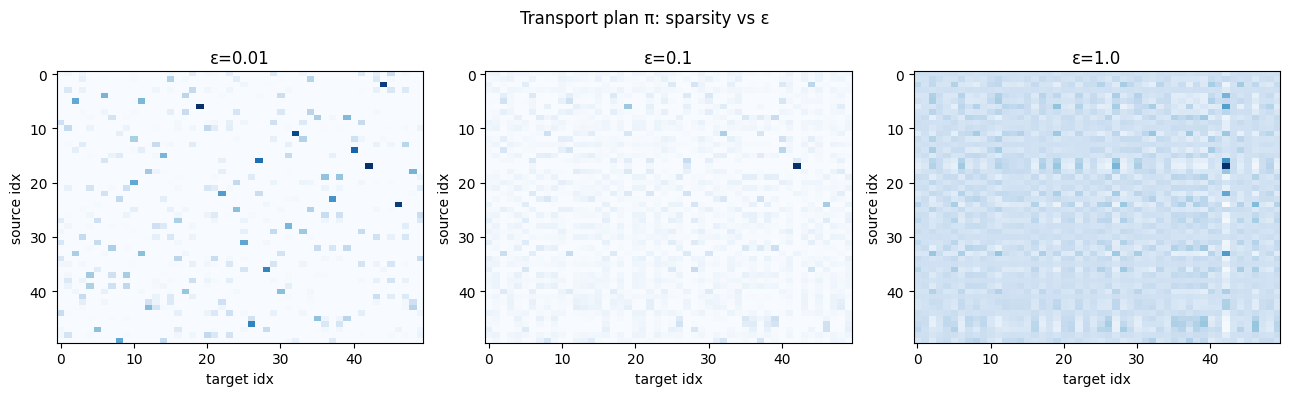

In [29]:
# cell 29 - effect of epsilon on transport plan
X2 = torch.randn(50, 2) * 0.3
Y2 = torch.randn(50, 2) * 0.3 + torch.tensor([2., 0.])

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, eps in zip(axes, [0.01, 0.1, 1.0]):
    # build transport plan manually
    C = torch.cdist(X2, Y2) ** 2
    a = torch.ones(50)/50; b = torch.ones(50)/50
    f = torch.zeros(50); g = torch.zeros(50)
    for _ in range(300):
        f = eps*(torch.log(a) - torch.logsumexp((g-C)/eps, dim=1))
        g = eps*(torch.log(b) - torch.logsumexp((f.unsqueeze(1)-C)/eps, dim=0))
    pi = torch.exp((f.unsqueeze(1)+g.unsqueeze(0)-C)/eps).numpy()

    ax.imshow(pi, cmap='Blues', aspect='auto')
    ax.set_title(f"ε={eps}"); ax.set_xlabel("target idx"); ax.set_ylabel("source idx")

plt.suptitle("Transport plan π: sparsity vs ε")
plt.tight_layout(); plt.show()

In [30]:
# cell 30 — shared encoder (small ConvNet, domain-agnostic)
class Encoder(nn.Module):
    def __init__(self, embed_dim=128, normalize=True, align_head=False):
        super().__init__()
        self.normalize = normalize
        self.align_head = align_head

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, embed_dim),
            nn.ReLU(),
        )

        if align_head:
            self.fc_align = nn.Sequential(
                nn.Linear(128*4*4, embed_dim),
                nn.BatchNorm1d(embed_dim), # added stabilization against feature drift
                nn.ReLU(),
            )

    def forward(self, x):
        z = self.fc(self.conv(x))
        return F.normalize(z, dim=1) # always normalize for ce/classifier

    def forward_align(self, x):
        conv_out = self.conv(x).flatten(1)
        if not self.align_head:
            z = self.fc(conv_out)
            return F.normalize(z, dim=1) if self.normalize else z

        z = self.fc_align(conv_out)
        return F.normalize(z, dim=1) if self.normalize else z


class Classifier(nn.Module):
    """linear head on top of encoder embeddings."""
    def __init__(self, embed_dim=128, n_classes=10):
        super().__init__()
        self.head = nn.Linear(embed_dim, n_classes)

    def forward(self, z):
        return self.head(z)

In [31]:
# cell 31 - unified transforms: both domains -> 3x32x32 float tensors
mnist_transform_adapted = transforms.Compose([
    transforms.Resize(32),
    transforms.Grayscale(num_output_channels=3), # replicate to 3ch
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
])
svhn_transform_adapted = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
])

mnist_train_adapted = torchvision.datasets.MNIST(root='/kaggle/working/data', train=True, transform=mnist_transform_adapted)
svhn_train_adapted  = torchvision.datasets.SVHN(root='/kaggle/working/data', split='train', transform=svhn_transform_adapted)
svhn_test_adapted = torchvision.datasets.SVHN(root='/kaggle/working/data', split='test', transform=svhn_transform_adapted)

print(f"MNIST sample shape: {mnist_train_adapted[0][0].shape}")
print(f"SVHN sample shape: {svhn_train_adapted[0][0].shape}")

MNIST sample shape: torch.Size([3, 32, 32])
SVHN sample shape: torch.Size([3, 32, 32])


In [32]:
# cell 32 - dataloaders
BATCH_SIZE = 256

mnist_loader = DataLoader(mnist_train_adapted, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, drop_last=True)
svhn_loader = DataLoader(svhn_train_adapted,  batch_size=BATCH_SIZE, shuffle=True, num_workers=4, drop_last=True)
svhn_test_loader = DataLoader(svhn_test_adapted, batch_size=512, shuffle=False, num_workers=4)

print(f"MNIST batches/epoch: {len(mnist_loader)}")
print(f"SVHN batches/epoch: {len(svhn_loader)}")

MNIST batches/epoch: 234
SVHN batches/epoch: 286


In [33]:
# cell 33 - plug-in alignment loss selector with projection variance adjustment
def sinkhorn_log_stable(Zs, Zt, eps=1.0, n_iter=50):
    """Stable log-domain custom Sinkhorn implementation."""
    # compute squared euclidean cost matrix
    C = torch.cdist(Zs, Zt, p=2)**2

    # initialize dual variables in log space
    f = torch.zeros(Zs.shape[0], device=Zs.device)
    g = torch.zeros(Zt.shape[0], device=Zt.device)

    # fixed marginals (uniform)
    log_mu = torch.log(torch.tensor(1.0 / Zs.shape[0], device=Zs.device))
    log_nu = torch.log(torch.tensor(1.0 / Zt.shape[0], device=Zt.device))

    for _ in range(n_iter):
        # update f in log domain: f = eps * (log(mu) - logsumexp((g - C)/eps))
        M1 = (g.unsqueeze(0) - C) / eps
        f = eps * (log_mu - torch.logsumexp(M1, dim=1))

        # update g in log domain: g = eps * (log(nu) - logsumexp((f - C)/eps))
        M2 = (f.unsqueeze(1) - C) / eps
        g = eps * (log_nu - torch.logsumexp(M2, dim=0))

    # compute final wasserstein distance plan projection
    M_final = (f.unsqueeze(1) + g.unsqueeze(0) - C) / eps
    P = torch.exp(M_final)
    return torch.sum(P * C)


def alignment_loss(Zs, Zt, method='swd', n_proj=200, eps=1.0):
    if method == 'none':
        return torch.tensor(0.0, device=Zs.device)

    elif method == 'swd':
        d = Zs.shape[1]
        scale = np.sqrt(d) # scaling factor to counteract 128-D projection decay
        thetas = torch.randn(n_proj, d, device=Zs.device)
        thetas = thetas / (thetas.norm(dim=1, keepdim=True) + 1e-8)

        Xp = (Zs @ thetas.T).T.sort(dim=1).values * scale
        Yp = (Zt @ thetas.T).T.sort(dim=1).values * scale
        return ((Xp - Yp)**2).mean()

    elif method == 'max_swd':
        d = Zs.shape[1]
        scale = np.sqrt(d) # scaling factor to counteract 128-D projection decay
        theta = torch.randn(d, device=Zs.device)
        theta = (theta / (theta.norm() + 1e-8)).detach().requires_grad_(True)

        for _ in range(10):
            loss = -((Zs.detach() @ theta).sort().values -
                     (Zt.detach() @ theta).sort().values).pow(2).mean() * scale
            loss.backward()
            with torch.no_grad():
                theta.data = theta.data - 0.05 * theta.grad
                theta.data = theta.data / (theta.data.norm() + 1e-8)
            theta.grad.zero_()

        xp = (Zs @ theta.detach()).sort().values * scale
        yp = (Zt @ theta.detach()).sort().values * scale
        return ((xp - yp)**2).mean()

    elif method == 'sinkhorn':
        return sinkhorn_log_stable(Zs, Zt, eps=eps, n_iter=50)

    else:
        raise ValueError(f"unknown method: {method}")

In [34]:
# cell 34 - sanity check: forward pass through encoder + classifier
enc = Encoder(embed_dim=128).to(device)
clf = Classifier(embed_dim=128).to(device)

dummy = torch.randn(8, 3, 32, 32).to(device)
z = enc(dummy)
logits = clf(z)
print(f"Input: {dummy.shape}")
print(f"Embed: {z.shape}")
print(f"Logits: {logits.shape}")
print(f"Encoder params: {sum(p.numel() for p in enc.parameters()):,}")
total = sum(p.numel() for p in list(enc.parameters())+list(clf.parameters()))
print(f"Total params: {total:,}")

Input: torch.Size([8, 3, 32, 32])
Embed: torch.Size([8, 128])
Logits: torch.Size([8, 10])
Encoder params: 355,968
Total params: 357,258


In [35]:
# cell 35 - training utilities with gradient clipping
def evaluate(enc, clf, loader, device):
    """target accuracy — no labels used during training."""
    enc.eval(); clf.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            correct += (clf(enc(x)).argmax(1) == y).sum().item()
            total += len(y)
    return correct / total

def train_epoch(enc, clf, opt, mnist_loader, svhn_loader, method, lam, device):
    enc.train(); clf.train()
    ce_losses, align_losses = [], []
    svhn_iter = iter(svhn_loader)

    for (xs, ys) in mnist_loader:
        try:
            xt, _ = next(svhn_iter)
        except StopIteration:
            svhn_iter = iter(svhn_loader); xt, _ = next(svhn_iter)

        xs, ys, xt = xs.to(device), ys.to(device), xt.to(device)

        # 1. source classification loss step
        Zs = enc(xs)
        ce = F.cross_entropy(clf(Zs), ys, label_smoothing=0.1)

        # 2. joint domain unsupervised alignment step
        if method != 'none':
            Zs_a = enc.forward_align(xs)
            Zt_a = enc.forward_align(xt)
            alg = alignment_loss(Zs_a, Zt_a, method=method)
        else:
            alg = torch.tensor(0.0, device=device)

        # combined loss where gradients cleanly distribute backward through enc.conv
        loss = ce + lam * alg

        opt.zero_grad()
        loss.backward()

        # clip joint parameters uniformly to prevent optimizer explosion
        torch.nn.utils.clip_grad_norm_(
            list(enc.parameters()) + list(clf.parameters()), max_norm=5.0)
        opt.step()

        ce_losses.append(ce.item())
        align_losses.append(alg.item() if isinstance(alg, torch.Tensor) else float(alg))

    return np.mean(ce_losses), np.mean(align_losses)

In [36]:
# cell 36 - full training loop with method-specific lambdas
LAM = {'none': 0.0, 'swd': 0.08, 'max_swd': 0.04, 'sinkhorn': 0.05}
NORMALIZE = {'none': True, 'swd': True, 'max_swd': True, 'sinkhorn': True} 
ALIGN_HEAD = {'none': False, 'swd': True, 'max_swd': True, 'sinkhorn': False}

def run_experiment(method, lam=None, n_epochs=20, embed_dim=128, seed=SEED):
    lam = lam if lam is not None else LAM[method]
    
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    enc = Encoder(embed_dim=embed_dim, normalize=NORMALIZE[method], align_head=ALIGN_HEAD[method]).to(device)
    clf = Classifier(embed_dim=embed_dim).to(device)
    opt = Adam(
        list(enc.parameters()) + list(clf.parameters()),
        lr=3e-4, weight_decay=1e-3
    )
    sch = CosineAnnealingLR(opt, T_max=n_epochs)

    history = {'ce': [], 'align': [], 'target_acc': [], 'epoch_time': [], 'lam': lam, 'best_acc': 0.0}
    best_epoch = 0

    pbar = tqdm(range(n_epochs), desc=f"[{method}|λ={lam}]", unit="epoch")
    for epoch in pbar:
        t0 = time.perf_counter()
        ce, alg = train_epoch(enc, clf, opt, mnist_loader, svhn_loader, method, lam, device)
        sch.step()
        acc = evaluate(enc, clf, svhn_test_loader, device)
        if acc > history['best_acc']:
            history['best_acc'] = acc
            best_epoch = epoch + 1
        elapsed = time.perf_counter() - t0

        history['ce'].append(ce)
        history['align'].append(alg)
        history['target_acc'].append(acc)
        history['epoch_time'].append(elapsed)

        ratio = lam * alg / (ce + 1e-8)
        overfit_flag = "OVERFIT" if ce < 0.005 and epoch < 10 else "OK"
        pbar.set_postfix(CE=f"{ce:.4f}", ratio=f"{ratio:.3f}", acc=f"{acc:.4f}")
        print(f"[{method}] epoch {epoch+1:02d} | "
              f"CE={ce:.4f} λ·align={lam*alg:.5f} ratio={ratio:.3f} "
              f"target_acc={acc:.4f} best={history['best_acc']:.4f}@ep{best_epoch} "
              f"time={elapsed:.1f}s [{overfit_flag}]")

    return history

In [37]:
# cell 37 - diagnostic check then full run
print("DIAGNOSTIC: loss scales after epoch 1\n")
print(f"{'method':<12} {'CE':>8} {'align':>12} {'λ·align':>10} {'ratio':>8}  status")
print("-"*60)
for method in ['swd', 'max_swd', 'sinkhorn']:
    enc_tmp = Encoder(embed_dim=128).to(device)
    clf_tmp = Classifier(embed_dim=128).to(device)
    opt_tmp = Adam(list(enc_tmp.parameters()) + list(clf_tmp.parameters()), lr=1e-3)
    ce, alg = train_epoch(enc_tmp, clf_tmp, opt_tmp, mnist_loader, svhn_loader, method, LAM[method], device)
    ratio = LAM[method] * alg / (ce + 1e-8)
    status = "OK" if ratio < 0.5 else "REDUCE LAM"
    print(f"{method:<12} {ce:>8.4f} {alg:>12.6f} {LAM[method]*alg:>10.5f} {ratio:>8.4f}  {status}")

print("\nProceeding to full run if all statuses report OK...\n")

# full run
results = {}
for method in ['none', 'swd', 'max_swd', 'sinkhorn']:
    print(f"\n{'='*60}\n{method.upper()}")
    results[method] = run_experiment(method)

DIAGNOSTIC: loss scales after epoch 1

method             CE        align    λ·align    ratio  status
------------------------------------------------------------
swd            1.5266     0.051086    0.00409   0.0027  OK
max_swd        1.7050     0.369807    0.01479   0.0087  OK
sinkhorn       1.5634     0.767345    0.03837   0.0245  OK

Proceeding to full run if all statuses report OK...


NONE


[none|λ=0.0]:   5%|▌         | 1/20 [00:19<06:12, 19.61s/epoch, CE=1.8929, acc=0.2239, ratio=0.000]

[none] epoch 01 | CE=1.8929 λ·align=0.00000 ratio=0.000 target_acc=0.2239 best=0.2239@ep1 time=19.6s [OK]


[none|λ=0.0]:  10%|█         | 2/20 [00:39<05:53, 19.66s/epoch, CE=1.4960, acc=0.2327, ratio=0.000]

[none] epoch 02 | CE=1.4960 λ·align=0.00000 ratio=0.000 target_acc=0.2327 best=0.2327@ep2 time=19.7s [OK]


...

[sinkhorn] epoch 18 | CE=0.5397 λ·align=0.04003 ratio=0.074 target_acc=0.1875 best=0.2707@ep2 time=26.6s [OK]


[sinkhorn|λ=0.05]:  95%|█████████▌| 19/20 [08:22<00:26, 26.53s/epoch, CE=0.5389, acc=0.1804, ratio=0.074]

[sinkhorn] epoch 19 | CE=0.5389 λ·align=0.04002 ratio=0.074 target_acc=0.1804 best=0.2707@ep2 time=26.6s [OK]


[sinkhorn|λ=0.05]: 100%|██████████| 20/20 [08:49<00:00, 26.46s/epoch, CE=0.5385, acc=0.1848, ratio=0.074]

[sinkhorn] epoch 20 | CE=0.5385 λ·align=0.04001 ratio=0.074 target_acc=0.1848 best=0.2707@ep2 time=26.4s [OK]


In [38]:
# cell 38 - report
print("REPORT\n")

# 1. overfitting check - ce should not collapse below 0.05 before epoch 10
print("\n[1] CE TRAJECTORY (overfit check — should stay > 0.05 for epochs 1-10)\n")
print(f"{'Method':<12} " + " ".join(f"ep{i+1:02d}" for i in range(10)))
print("-" * 120)
for method, hist in results.items():
    ces = hist['ce'][:10]
    flags = ["!" if c < 0.005 else " " for c in ces]
    vals = " ".join(f"{c:.3f}{f}" for c, f in zip(ces, flags))
    print(f"{method:<12} {vals}")

# 2. lambda·align / ce ratio - should stay 0.05-0.3 throughout
print("\n[2] λ·ALIGN/CE RATIO PER EPOCH (target: 0.05–0.30)\n")
print(f"{'Method':<12} " + " ".join(f"ep{i+1:02d}" for i in range(20)))
print("-" * 120)
for method, hist in results.items():
    lam = hist['lam']
    ratios = [lam * a / (c + 1e-8) for a, c in zip(hist['align'], hist['ce'])]
    flags = ["!" if (r < 0.01 or r > 0.5) else " " for r in ratios]
    vals = " ".join(f"{r:.2f}{f}" for r, f in zip(ratios, flags))
    print(f"{method:<12} {vals}")

# 3. accuracy trend - alignment methods should beat none, monotonically increasing
print("\n[3] TARGET ACCURACY PER EPOCH\n")
print(f"{'Method':<12} " + " ".join(f"ep{i+1:02d}" for i in range(20)))
print("-" * 120)
for method, hist in results.items():
    accs = hist['target_acc']
    vals = " ".join(f"{a:.3f}" for a in accs)
    print(f"{method:<12} {vals}")

# 4. summary table 1
print("\n[4] SUMMARY\n")
print(f"{'Method':<12} {'Best Acc':>9} {'Beat None?':>11} {'CE ep20':>8} {'Avg Ratio':>10} {'Ratio OK?':>10}")
print("-" * 120)
none_best = results['none']['best_acc']
for method, hist in results.items():
    lam = hist['lam']
    ratios = [lam * a / (c + 1e-8) for a, c in zip(hist['align'], hist['ce'])]
    avg_ratio = np.mean(ratios)
    ratio_ok = all(0.01 < r < 0.5 for r in ratios) if method != 'none' else True
    beat = "✓" if hist['best_acc'] > none_best else "✗"
    print(f"{method:<12} {hist['best_acc']:>9.4f} {beat:>11} "
          f"{hist['ce'][-1]:>8.4f} {avg_ratio:>10.4f} {'✓' if ratio_ok else '✗':>10}")

# 4.5 summary table 2
print("\n[4.5] SYNTHESIS\n")
print(f"\n{'Method':<12} {'Final Acc':>10} {'Best Acc':>9} {'Avg Time/Epoch':>15} {'λ·Align (avg)':>14}")
print("-"*120)
for method, hist in results.items():
    lam = hist['lam']
    print(f"{method:<12} "
          f"{hist['target_acc'][-1]:>10.4f} "
          f"{hist['best_acc']:>9.4f} "
          f"{np.mean(hist['epoch_time']):>15.1f}s "
          f"{np.mean(hist['align'])*lam:>14.5f}")

# 5. monotonicity check for swd/max_swd
print("\n[5] MONOTONICITY CHECK (acc should trend upward, not collapse after ep2)\n")
for method in ['swd', 'max_swd', 'sinkhorn']:
    accs = results[method]['target_acc']
    peak_ep = int(np.argmax(accs)) + 1
    final = accs[-1]
    peak = max(accs)
    drop = peak - final
    trend = "GOOD" if peak_ep >= 5 and drop < 0.05 else f"PEAKED ep{peak_ep}, dropped {drop:.3f}"
    print(f" {method:<12}  peak={peak:.4f}  @ep{peak_ep}  final={final:.4f} {trend}")

print("\n[6] PASS/FAIL\n")
all_beat = all(results[m]['best_acc'] > none_best for m in ['swd', 'max_swd', 'sinkhorn'])
no_overfit = all(results[m]['ce'][9] > 0.005 for m in results) # ce at epoch 10
print(f" All alignment methods beat none: {'PASS' if all_beat else 'FAIL'}")
print(f" No CE collapse by epoch 10: {'PASS' if no_overfit else 'FAIL'}")

REPORT


[1] CE TRAJECTORY (overfit check — should stay > 0.05 for epochs 1-10)

Method       ep01 ep02 ep03 ep04 ep05 ep06 ep07 ep08 ep09 ep10
------------------------------------------------------------------------------------------------------------------------
none         1.893  1.496  1.199  0.987  0.844  0.747  0.682  0.638  0.608  0.586 
swd          1.884  1.489  1.194  0.984  0.840  0.745  0.681  0.638  0.608  0.586 
max_swd      1.889  1.493  1.198  0.988  0.842  0.745  0.680  0.636  0.606  0.585 
sinkhorn     1.915  1.524  1.232  1.018  0.870  0.768  0.699  0.651  0.618  0.595 

[2] λ·ALIGN/CE RATIO PER EPOCH (target: 0.05–0.30)

Method       ep01 ep02 ep03 ep04 ep05 ep06 ep07 ep08 ep09 ep10 ep11 ep12 ep13 ep14 ep15 ep16 ep17 ep18 ep19 ep20
------------------------------------------------------------------------------------------------------------------------
none         0.00! 0.00! 0.00! 0.00! 0.00! 0.00! 0.00! 0.00! 0.00! 0.00! 0.00! 0.00! 0.00! 0.00! 0.00! 0.00! 0.00! 0

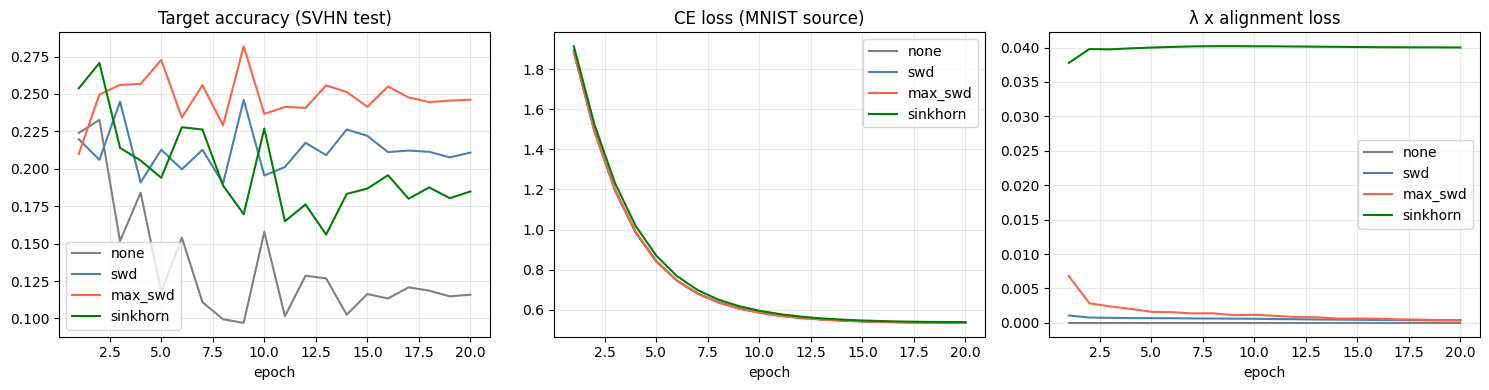

In [39]:
# cell 39 - learning curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {'none':'gray', 'swd':'steelblue', 'max_swd':'tomato', 'sinkhorn':'green'}

for method, hist in results.items():
    lam = hist['lam']
    epochs = range(1, len(hist['target_acc']) + 1)
    axes[0].plot(epochs, hist['target_acc'], color=colors[method], label=method)
    axes[1].plot(epochs, hist['ce'], color=colors[method], label=method)
    axes[2].plot(epochs, [lam*a for a in hist['align']], color=colors[method], label=method)

axes[0].set_title("Target accuracy (SVHN test)"); axes[0].set_xlabel("epoch")
axes[1].set_title("CE loss (MNIST source)"); axes[1].set_xlabel("epoch")
axes[2].set_title("λ x alignment loss"); axes[2].set_xlabel("epoch")
for ax in axes: ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [40]:
# cell 40 - SWD variance measurement across L and d
def swd_variance_experiment(X, Y, Ls, n_trials=20):
    """
    For each L, run n_trials independent SWD estimates.
    Returns dict L -> (mean, std, cv) where cv = std/mean.
    """
    results = {}
    for L in Ls:
        estimates = [
            sliced_wasserstein(X, Y, n_proj=L, seed=s)
            for s in range(n_trials)
        ]
        mean = np.mean(estimates)
        std = np.std(estimates)
        results[L] = (mean, std, std/mean if mean > 0 else 0)
    return results

In [41]:
# cell 41 - ablation across L for multiple embedding dims
Ls = [10, 50, 100, 500, 1000, 2000, 5000]
dims = [8, 32, 128]

ablation = {} # dim -> {L -> (mean, std, cv)}
for d in dims:
    X = torch.randn(500, d)
    Y = torch.randn(500, d) + 0.5 # fixed shift for comparability
    ablation[d] = swd_variance_experiment(X, Y, Ls, n_trials=20)
    print(f"\nd={d}")
    print(f"{'L':>6}  {'mean':>10} {'std':>10} {'cv (std/mean)':>14} {'converged':>10}")
    ref = ablation[d][Ls[-1]][0]
    for L in Ls:
        mean, std, cv = ablation[d][L]
        converged = "YES" if cv < 0.01 else "no"
        print(f"{L:>6} {mean:>10.4f} {std:>10.4f} {cv:>14.4f} {converged:>10}")


d=8
     L        mean        std  cv (std/mean)  converged
    10     0.2563     0.0700         0.2730         no
    50     0.2354     0.0417         0.1774         no
   100     0.2286     0.0313         0.1368         no
   500     0.2320     0.0112         0.0485         no
  1000     0.2302     0.0077         0.0333         no
  2000     0.2307     0.0052         0.0224         no
  5000     0.2307     0.0037         0.0161         no

d=32
     L        mean        std  cv (std/mean)  converged
    10     0.2179     0.0911         0.4180         no
    50     0.2459     0.0445         0.1810         no
   100     0.2554     0.0319         0.1249         no
   500     0.2550     0.0134         0.0524         no
  1000     0.2534     0.0086         0.0339         no
  2000     0.2511     0.0043         0.0172         no
  5000     0.2521     0.0042         0.0166         no

d=128
     L        mean        std  cv (std/mean)  converged
    10     0.2464     0.0944         0.3833 

In [42]:
# cell 42 - identify minimum L for convergence (practical threshold cv < 5%)
THRESHOLD = 0.05
print(f"\n{'d':>6}  {'min L (cv<5%)':>14}  {'cv at that L':>14}")
print("-"*40)
for d in dims:
    min_L = None
    for L in Ls:
        if ablation[d][L][2] < THRESHOLD:
            min_L = L; break
    cv_val = ablation[d][min_L][2] if min_L else ablation[d][Ls[-1]][2]
    print(f"{d:>6} {str(min_L) if min_L else '>5000':>14} {cv_val:>14.4f}")


     d   min L (cv<5%)    cv at that L
----------------------------------------
     8            500         0.0485
    32           1000         0.0339
   128           1000         0.0395


In [43]:
# cell 43 - wall-clock time vs L
print(f"\n{'L':>6}  {'time (ms)':>12}")
print("-"*22)
X128 = torch.randn(500, 128)
Y128 = torch.randn(500, 128) + 0.5
for L in Ls:
    t0 = time.perf_counter()
    for _ in range(20): sliced_wasserstein(X128, Y128, n_proj=L)
    t = (time.perf_counter() - t0) / 20 * 1000
    print(f"{L:>6} {t:>12.2f}")


     L     time (ms)
----------------------
    10         1.21
    50         3.71
   100         4.03
   500        18.36
  1000        36.82
  2000        75.21
  5000       217.38


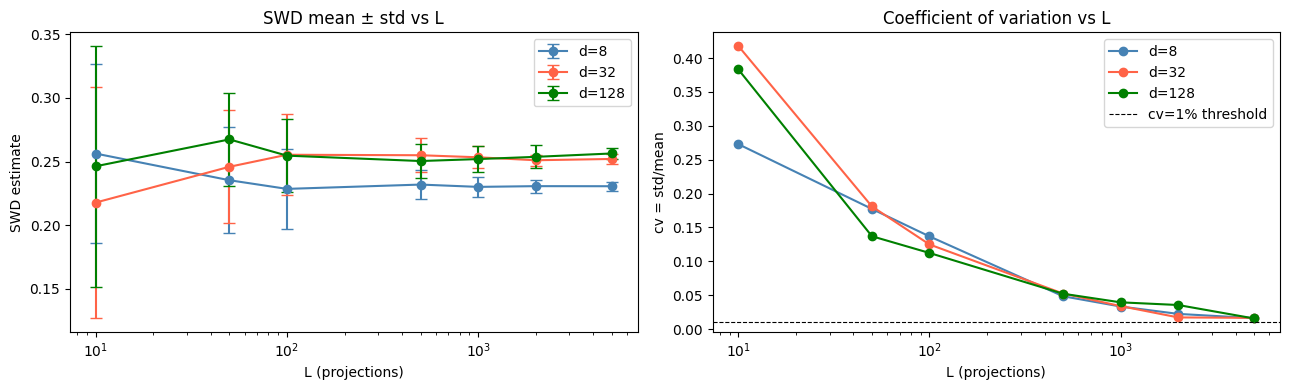

In [44]:
# cell 44 - convergence plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = {8: 'steelblue', 32: 'tomato', 128: 'green'}

for d in dims:
    means = [ablation[d][L][0] for L in Ls]
    stds = [ablation[d][L][1] for L in Ls]
    axes[0].errorbar(Ls, means, yerr=stds, fmt='o-', capsize=4, color=colors[d], label=f'd={d}')
    axes[1].plot(Ls, [ablation[d][L][2] for L in Ls], 'o-', color=colors[d], label=f'd={d}')

axes[0].set_xscale('log'); axes[0].set_xlabel("L (projections)")
axes[0].set_ylabel("SWD estimate"); axes[0].set_title("SWD mean ± std vs L")
axes[0].legend()

axes[1].axhline(0.01, color='k', ls='--', lw=0.8, label='cv=1% threshold')
axes[1].set_xscale('log'); axes[1].set_xlabel("L (projections)")
axes[1].set_ylabel("cv = std/mean"); axes[1].set_title("Coefficient of variation vs L")
axes[1].legend()

plt.tight_layout(); plt.show()

In [45]:
# cell 45 - benchmark table using best results from all stages
benchmark = {
    'Method': ['No Adapt', 'SWD', 'Max-SWD', 'Sinkhorn'],
    'Best Acc': [results['none']['best_acc'], 
                 results['swd']['best_acc'],
                 results['max_swd']['best_acc'],
                 results['sinkhorn']['best_acc']],
    'Final Acc': [results[m]['target_acc'][-1] for m in ['none','swd','max_swd','sinkhorn']],
    'Time/Epoch': [f"{np.mean(results[m]['epoch_time']):.1f}s" for m in ['none','swd','max_swd','sinkhorn']],
    'λ·Align (avg)': [f"{np.mean(results[m]['align'])*results[m]['lam']:.5f}" for m in ['none','swd','max_swd','sinkhorn']],
}
df = pd.DataFrame(benchmark)
print(df.to_string(index=False))

  Method  Best Acc  Final Acc Time/Epoch λ·Align (avg)
No Adapt  0.232675   0.115896      19.5s       0.00000
     SWD  0.246043   0.210779      20.1s       0.00058
 Max-SWD  0.281922   0.246120      21.5s       0.00144
Sinkhorn  0.270667   0.184849      26.5s       0.03994


In [46]:
# cell 46 - projection ablation summary table
print("\nProjection ablation (d=128, n=500 samples, 20 trials per L):\n")
print(f"{'L':>6} {'mean SWD':>10} {'std':>8} {'cv':>8} {'time(ms)':>10} {'converged(cv<5%)':>18}")
print("-"*68)
X128 = torch.randn(500, 128)
Y128 = torch.randn(500, 128) + 0.5
for L in Ls:
    mean, std, cv = ablation[128][L]
    t0 = time.perf_counter()
    for _ in range(20): sliced_wasserstein(X128, Y128, n_proj=L)
    t_ms = (time.perf_counter() - t0) / 20 * 1000
    conv = "YES" if cv < 0.05 else "no"
    print(f"{L:>6} {mean:>10.4f} {std:>8.4f} {cv:>8.4f} {t_ms:>10.2f} {conv:>18}")


Projection ablation (d=128, n=500 samples, 20 trials per L):

     L   mean SWD      std       cv   time(ms)   converged(cv<5%)
--------------------------------------------------------------------
    10     0.2464   0.0944   0.3833       1.13                 no
    50     0.2674   0.0367   0.1371       3.48                 no
   100     0.2547   0.0286   0.1124       3.83                 no
   500     0.2505   0.0131   0.0522      17.42                 no
  1000     0.2520   0.0099   0.0395      35.70                YES
  2000     0.2537   0.0090   0.0355      76.64                YES
  5000     0.2564   0.0040   0.0156     213.42                YES


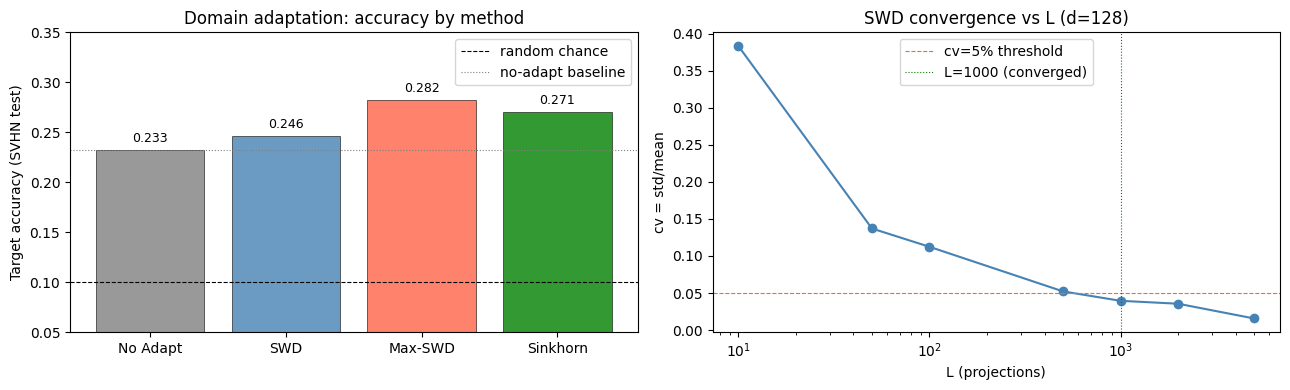

In [47]:
# cell 47 - final combined plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# left: accuracy vs method bar chart
methods = ['No Adapt', 'SWD', 'Max-SWD', 'Sinkhorn']
accs = [results[m]['best_acc'] for m in ['none', 'swd', 'max_swd', 'sinkhorn']]
colors = ['gray', 'steelblue', 'tomato', 'green']
bars = axes[0].bar(methods, accs, color=colors, alpha=0.8, edgecolor='black', lw=0.5)
axes[0].axhline(0.10, color='k', ls='--', lw=0.8, label='random chance')
axes[0].axhline(accs[0], color='gray', ls=':', lw=0.8, label='no-adapt baseline')
axes[0].set_ylabel("Target accuracy (SVHN test)")
axes[0].set_title("Domain adaptation: accuracy by method")
axes[0].set_ylim(0.05, 0.35)
axes[0].legend()
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, acc + 0.005, f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

# right: SWD cv vs L (d=128)
cv_vals = [ablation[128][L][2] for L in Ls]
axes[1].plot(Ls, cv_vals, 'o-', color='steelblue')
axes[1].axhline(0.05, color='tomato', ls='--', lw=0.8, label='cv=5% threshold')
axes[1].axvline(1000, color='green', ls=':', lw=0.8, label='L=1000 (converged)')
axes[1].set_xscale('log')
axes[1].set_xlabel("L (projections)"); axes[1].set_ylabel("cv = std/mean")
axes[1].set_title("SWD convergence vs L (d=128)")
axes[1].legend()
plt.tight_layout(); plt.show()